# Autonomous Green Hydrogen Plant Controller Using Fuzzy Logic

This notebook adapts the instructional structure of the supplied Smart Irrigation Fuzzy Controller notebook to an autonomous green-hydrogen plant. A **Mamdani fuzzy logic controller (FLC)** regulates hydrogen production rate from renewable power, water flow, electrolyzer stack temperature, and hydrogen-tank pressure.

The controller specification, membership-function parameters, 11-rule knowledge base, and worked example are based on the supplied project PDF, *Autonomous Green Hydrogen Plant Controller*.


## Learning objectives

By completing this notebook, you will define linguistic variables, construct triangular membership functions, implement a Mamdani rule base, run the controller for plant sensor readings, compare defuzzification methods, and test how the production command changes under renewable intermittency and safety constraints.

> **Engineering note.** This is a simulation and educational controller. It is not a certified process-safety system and must not be connected to a live electrolyzer without validated operating limits, interlocks, sensor-fault handling, and qualified engineering review.


### Step 1: Install required libraries


In [ ]:
# Run this cell once in a fresh environment.
!pip install -q scikit-fuzzy matplotlib numpy pandas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 20.5 MB/s eta 0:00:00


### Step 2: Import libraries


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(precision=3, suppress=True)


## Step 3: Define input and output variables

The universes below follow the supplied project specification. Each sensor is represented by three linguistic terms, while the production command uses four terms.

| Variable | Role | Universe | Linguistic terms |
|---|---|---:|---|
| Renewable power | Input | 0–100 kW | Low, Medium, High |
| Water flow rate | Input | 0–20 L/min | Low, Medium, High |
| Stack temperature | Input | 20–80 °C | Low, Normal, High |
| Hydrogen-tank pressure | Input | 0–100 bar | Low, Medium, High |
| Hydrogen production rate | Output | 0–10 kg/h | Off, Low, Medium, High |


In [ ]:
# Four plant inputs and one controller output.
renewable_power = ctrl.Antecedent(np.arange(0, 101, 1), 'renewable_power')
water_flow = ctrl.Antecedent(np.arange(0, 21, 1), 'water_flow')
stack_temperature = ctrl.Antecedent(np.arange(20, 81, 1), 'stack_temperature')
tank_pressure = ctrl.Antecedent(np.arange(0, 101, 1), 'tank_pressure')
hydrogen_rate = ctrl.Consequent(np.arange(0, 10.01, 0.01), 'hydrogen_rate')


## Step 4: Define triangular membership functions

The triangular membership function is

\[
\mu(x) = \max\left(\min\left(rac{x-a}{b-a},rac{c-x}{c-b}
ight),0
ight),
\]

where `(a, b, c)` are the left foot, peak, and right foot. The shoulder functions use repeated endpoints such as `(0, 0, 50)` or `(50, 100, 100)`.


### 4.1 Renewable power: 0–100 kW


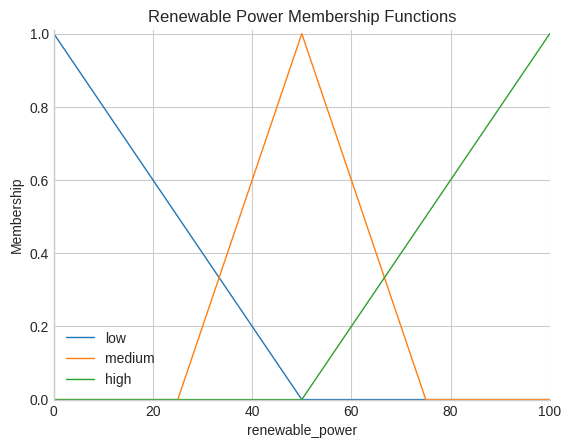

In [ ]:
renewable_power['low'] = fuzz.trimf(renewable_power.universe, [0, 0, 50])
renewable_power['medium'] = fuzz.trimf(renewable_power.universe, [25, 50, 75])
renewable_power['high'] = fuzz.trimf(renewable_power.universe, [50, 100, 100])
renewable_power.view()
plt.title('Renewable Power Membership Functions')
plt.show()


### 4.2 Water flow rate: 0–20 L/min


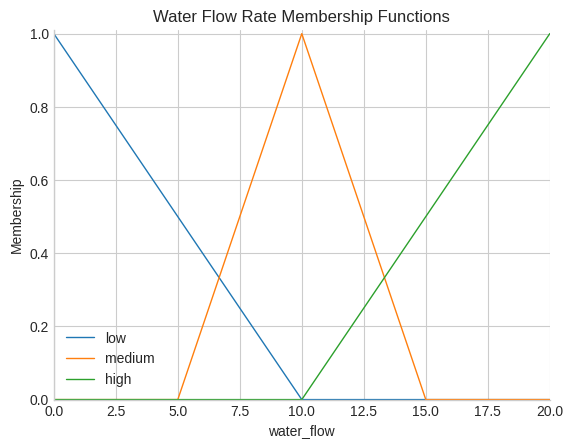

In [ ]:
water_flow['low'] = fuzz.trimf(water_flow.universe, [0, 0, 10])
water_flow['medium'] = fuzz.trimf(water_flow.universe, [5, 10, 15])
water_flow['high'] = fuzz.trimf(water_flow.universe, [10, 20, 20])
water_flow.view()
plt.title('Water Flow Rate Membership Functions')
plt.show()


### 4.3 Hydrogen-tank pressure: 0–100 bar

Pressure is safety-critical in this simplified controller: a high-pressure condition combined with low power and low flow produces an **Off** command.


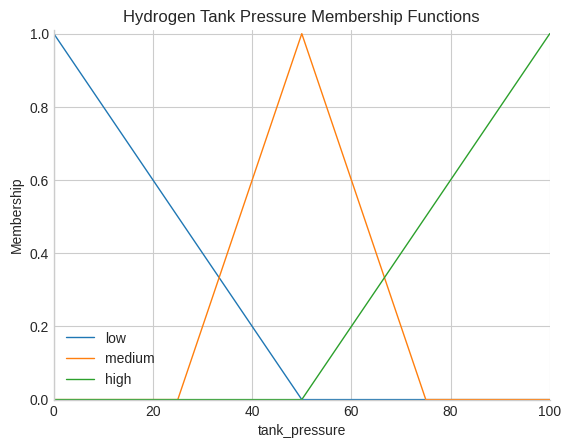

In [ ]:
tank_pressure['low'] = fuzz.trimf(tank_pressure.universe, [0, 0, 50])
tank_pressure['medium'] = fuzz.trimf(tank_pressure.universe, [25, 50, 75])
tank_pressure['high'] = fuzz.trimf(tank_pressure.universe, [50, 100, 100])
tank_pressure.view()
plt.title('Hydrogen Tank Pressure Membership Functions')
plt.show()


### 4.4 Electrolyzer stack temperature: 20–80 °C

The `Normal` term represents the preferred operating band.


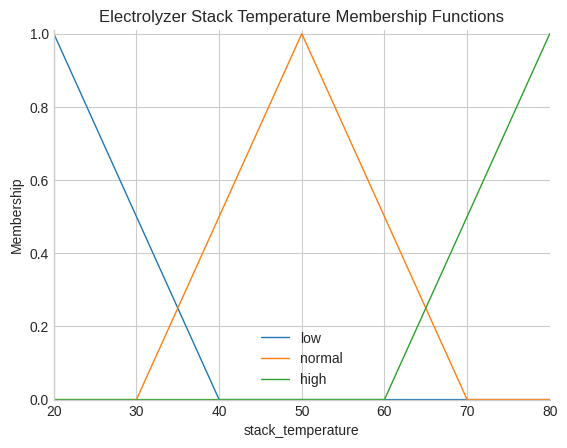

In [ ]:
stack_temperature['low'] = fuzz.trimf(stack_temperature.universe, [20, 20, 40])
stack_temperature['normal'] = fuzz.trimf(stack_temperature.universe, [30, 50, 70])
stack_temperature['high'] = fuzz.trimf(stack_temperature.universe, [60, 80, 80])
stack_temperature.view()
plt.title('Electrolyzer Stack Temperature Membership Functions')
plt.show()


### 4.5 Hydrogen production rate: 0–10 kg/h

The output terms use the peaks `Off → 1`, `Low → 3`, `Medium → 6`, and `High → 10` kg/h as representative values for the weighted-average illustration in the source project. The actual `scikit-fuzzy` controller uses Mamdani aggregation followed by the selected defuzzification method.


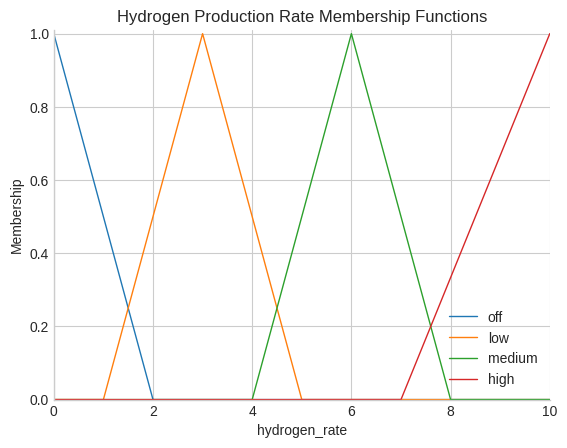

In [ ]:
hydrogen_rate['off'] = fuzz.trimf(hydrogen_rate.universe, [0, 0, 2])
hydrogen_rate['low'] = fuzz.trimf(hydrogen_rate.universe, [1, 3, 5])
hydrogen_rate['medium'] = fuzz.trimf(hydrogen_rate.universe, [4, 6, 8])
hydrogen_rate['high'] = fuzz.trimf(hydrogen_rate.universe, [7, 10, 10])
hydrogen_rate.view()
plt.title('Hydrogen Production Rate Membership Functions')
plt.show()


## Step 5: Inspect all membership functions together


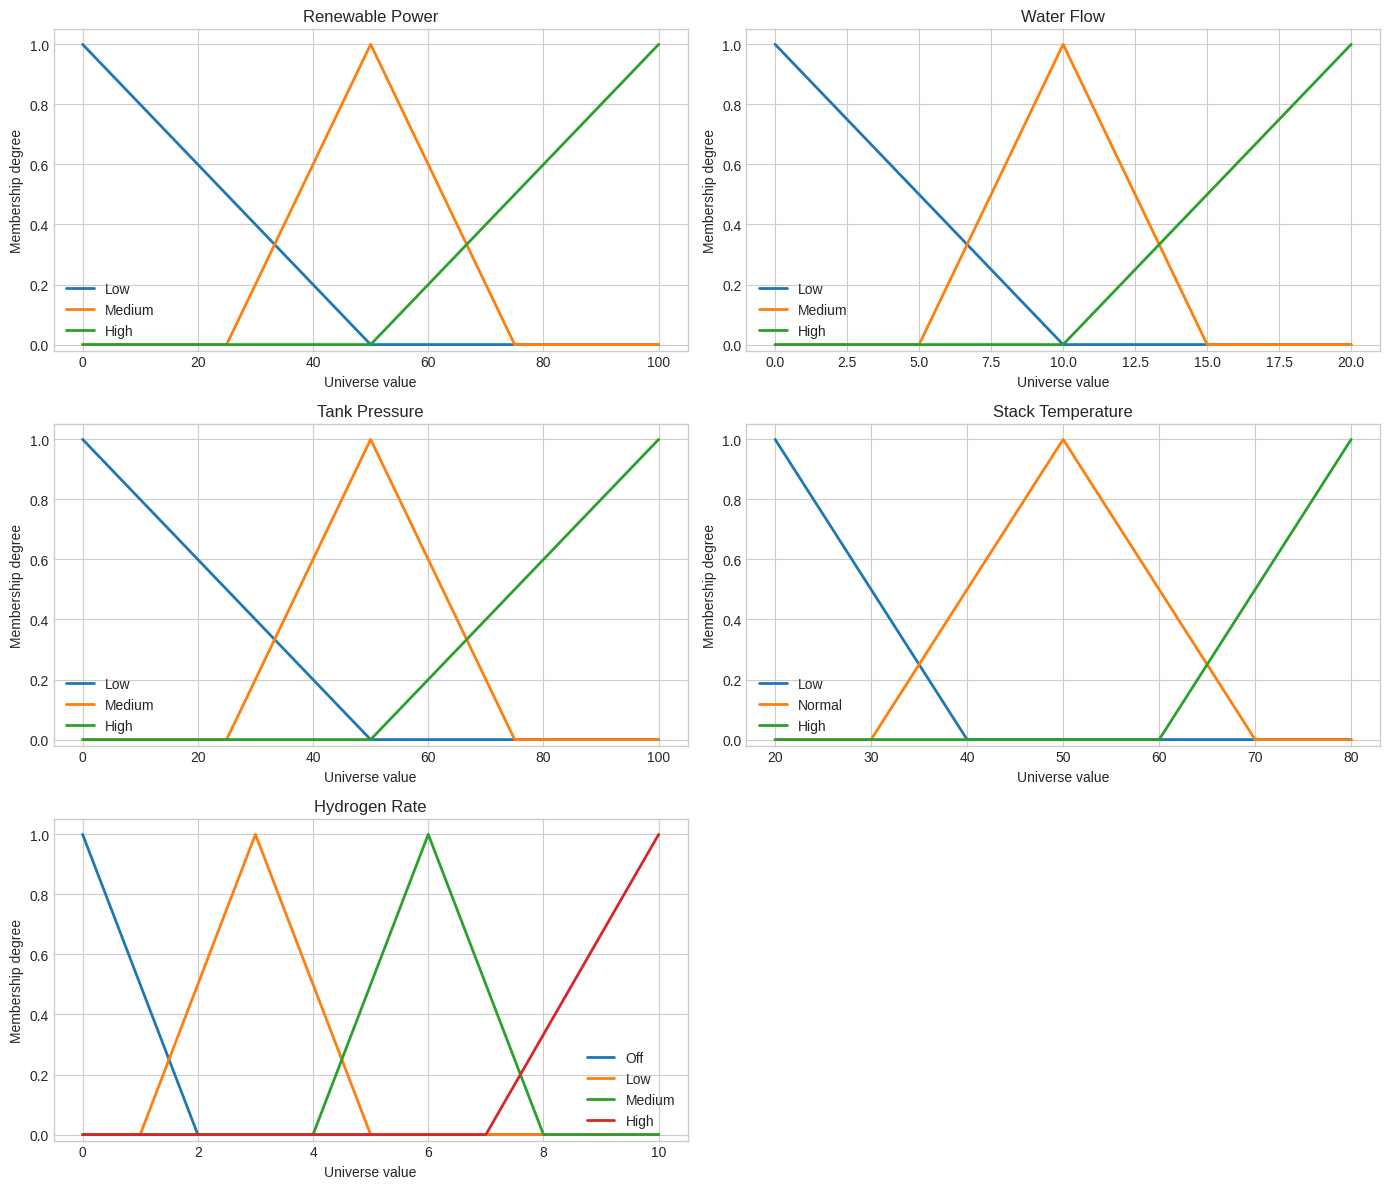

In [ ]:
variables = [renewable_power, water_flow, tank_pressure, stack_temperature, hydrogen_rate]
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
for ax, variable in zip(axes.flat, variables):
    for label, membership in variable.terms.items():
        ax.plot(variable.universe, membership.mf, linewidth=2, label=label.title())
    ax.set_title(variable.label.replace('_', ' ').title())
    ax.set_xlabel('Universe value')
    ax.set_ylabel('Membership degree')
    ax.set_ylim(-0.02, 1.05)
    ax.legend()
axes.flat[-1].axis('off')
plt.tight_layout()
plt.show()


## Step 6: Create the 11-rule expert knowledge base

The rule base follows the table in the supplied PDF. Rules R1–R10 assume a `Normal` stack temperature; R11 is a temperature-protection rule and intentionally leaves water flow and tank pressure unconstrained (`Any`). In each rule, the fuzzy AND operator uses the minimum antecedent membership.

| Rule | Renewable power | Water flow | Tank pressure | Temperature | Output |
|---|---|---|---|---|---|
| R1 | High | High | Low | Normal | High |
| R2 | High | Low | Low | Normal | Medium |
| R3 | Medium | Medium | Low | Normal | Medium |
| R4 | Medium | Low | Low | Normal | Medium |
| R5 | Low | High | Low | Normal | Medium |
| R6 | Low | Medium | Low | Normal | Low |
| R7 | Low | Low | Low | Normal | Low |
| R8 | High | High | Medium | Normal | High |
| R9 | High | Medium | Medium | Normal | Medium |
| R10 | Low | Low | High | Normal | Off |
| R11 | Medium | Any | Any | High | Low |


In [ ]:
rule1 = ctrl.Rule(
    renewable_power['high'] & water_flow['high'] & tank_pressure['low'] & stack_temperature['normal'],
    hydrogen_rate['high'])
rule2 = ctrl.Rule(
    renewable_power['high'] & water_flow['low'] & tank_pressure['low'] & stack_temperature['normal'],
    hydrogen_rate['medium'])
rule3 = ctrl.Rule(
    renewable_power['medium'] & water_flow['medium'] & tank_pressure['low'] & stack_temperature['normal'],
    hydrogen_rate['medium'])
rule4 = ctrl.Rule(
    renewable_power['medium'] & water_flow['low'] & tank_pressure['low'] & stack_temperature['normal'],
    hydrogen_rate['medium'])
rule5 = ctrl.Rule(
    renewable_power['low'] & water_flow['high'] & tank_pressure['low'] & stack_temperature['normal'],
    hydrogen_rate['medium'])
rule6 = ctrl.Rule(
    renewable_power['low'] & water_flow['medium'] & tank_pressure['low'] & stack_temperature['normal'],
    hydrogen_rate['low'])
rule7 = ctrl.Rule(
    renewable_power['low'] & water_flow['low'] & tank_pressure['low'] & stack_temperature['normal'],
    hydrogen_rate['low'])
rule8 = ctrl.Rule(
    renewable_power['high'] & water_flow['high'] & tank_pressure['medium'] & stack_temperature['normal'],
    hydrogen_rate['high'])
rule9 = ctrl.Rule(
    renewable_power['high'] & water_flow['medium'] & tank_pressure['medium'] & stack_temperature['normal'],
    hydrogen_rate['medium'])
rule10 = ctrl.Rule(
    renewable_power['low'] & water_flow['low'] & tank_pressure['high'] & stack_temperature['normal'],
    hydrogen_rate['off'])
rule11 = ctrl.Rule(
    renewable_power['medium'] & stack_temperature['high'],
    hydrogen_rate['low'])

rules = [rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9, rule10, rule11]
print(f'Number of fuzzy rules: {len(rules)}')


Number of fuzzy rules: 11


## Step 7: Create the Mamdani controller


In [ ]:
hydrogen_control = ctrl.ControlSystem(rules)
system = ctrl.ControlSystemSimulation(hydrogen_control)
print('Mamdani control system created successfully.')


Mamdani control system created successfully.


## Step 8: Fuzzify a live-plant example

The source project uses this sample sensor snapshot:

- Renewable power = **70 kW**
- Water flow rate = **14 L/min**
- Stack temperature = **50 °C**
- Tank pressure = **35 bar**

The helper below displays the membership degrees for all four inputs.


In [ ]:
sample_reading = {
    'renewable_power': 70,
    'water_flow': 14,
    'stack_temperature': 50,
    'tank_pressure': 35,
}

def memberships_for(variable, value):
    return {
        label: float(fuzz.interp_membership(variable.universe, term.mf, value))
        for label, term in variable.terms.items()
    }

input_variables = {
    'renewable_power': renewable_power,
    'water_flow': water_flow,
    'stack_temperature': stack_temperature,
    'tank_pressure': tank_pressure,
}

fuzzified = {
    name: memberships_for(input_variables[name], value)
    for name, value in sample_reading.items()
}

for name, degrees in fuzzified.items():
    print(f'{name}: {degrees}')


renewable_power: {'low': 0.0, 'medium': 0.2, 'high': 0.4}
water_flow: {'low': 0.0, 'medium': 0.2, 'high': 0.4}
stack_temperature: {'low': 0.0, 'normal': 1.0, 'high': 0.0}
tank_pressure: {'low': 0.3, 'medium': 0.4, 'high': 0.0}


## Step 9: Evaluate the rules and show firing strengths

For transparency, the next cell computes the 11 rule strengths directly from the membership degrees. The `Any` conditions in R11 are omitted from the minimum.


In [ ]:
def min_strength(*values):
    return min(values)

# The order of antecedent memberships matches the 11 rules above.
p = fuzzified['renewable_power']
w = fuzzified['water_flow']
t = fuzzified['stack_temperature']
q = fuzzified['tank_pressure']

rule_strengths = {
    'R1': min_strength(p['high'], w['high'], q['low'], t['normal']),
    'R2': min_strength(p['high'], w['low'], q['low'], t['normal']),
    'R3': min_strength(p['medium'], w['medium'], q['low'], t['normal']),
    'R4': min_strength(p['medium'], w['low'], q['low'], t['normal']),
    'R5': min_strength(p['low'], w['high'], q['low'], t['normal']),
    'R6': min_strength(p['low'], w['medium'], q['low'], t['normal']),
    'R7': min_strength(p['low'], w['low'], q['low'], t['normal']),
    'R8': min_strength(p['high'], w['high'], q['medium'], t['normal']),
    'R9': min_strength(p['high'], w['medium'], q['medium'], t['normal']),
    'R10': min_strength(p['low'], w['low'], q['high'], t['normal']),
    'R11': min_strength(p['medium'], t['high']),
}

rule_outputs = {
    'R1': 'high', 'R2': 'medium', 'R3': 'medium', 'R4': 'medium',
    'R5': 'medium', 'R6': 'low', 'R7': 'low', 'R8': 'high',
    'R9': 'medium', 'R10': 'off', 'R11': 'low'
}

fired_rules = pd.DataFrame([
    {'Rule': rule, 'Firing strength': strength, 'Output': rule_outputs[rule]}
    for rule, strength in rule_strengths.items() if strength > 0
])

if fired_rules.empty:
    print('No rule fired for this reading. Add a validated fallback policy before using such inputs.')
else:
    display(fired_rules.style.format({'Firing strength': '{:.2f}'}))


,Rule,Firing strength,Output
0,R1,0.30,high
1,R3,0.20,medium
2,R8,0.40,high
3,R9,0.20,medium


## Step 10: Run fuzzy inference and display the crisp command

The standard `scikit-fuzzy` pipeline performs Mamdani implication and aggregation, then applies the selected defuzzification method. The default is `centroid`, which returns the center of area of the aggregated output membership function.


In [ ]:
def run_controller(reading, defuzzification='centroid', show_output=True):
    hydrogen_rate.defuzzify_method = defuzzification
    sim = ctrl.ControlSystemSimulation(hydrogen_control)
    for variable_name, value in reading.items():
        sim.input[variable_name] = value
    sim.compute()
    result = float(sim.output['hydrogen_rate'])
    if show_output:
        print(f'Defuzzification method: {defuzzification}')
        print(f'Recommended hydrogen production rate: {result:.2f} kg/h')
    return sim, result

centroid_sim, centroid_result = run_controller(sample_reading, 'centroid')


Defuzzification method: centroid
Recommended hydrogen production rate: 7.59 kg/h


### Visualize the aggregated output and defuzzified command


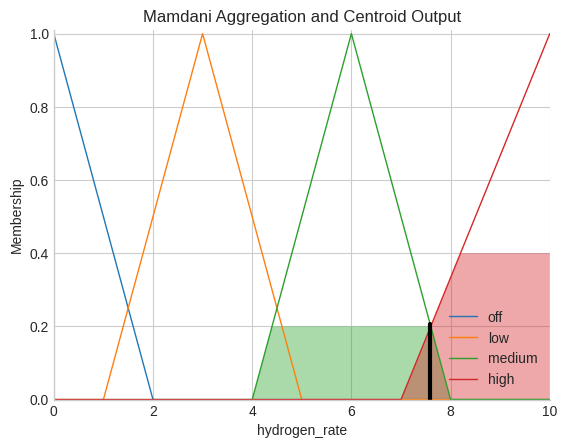

In [ ]:
hydrogen_rate.view(sim=centroid_sim)
plt.title('Mamdani Aggregation and Centroid Output')
plt.show()


## Step 11: Compare with the source PDF’s weighted-average illustration

The supplied PDF reports a weighted-average example using the **maximum firing strength per output term**:

\[y^* = rac{0.20	imes 6 + 0.40	imes 10}{0.20+0.40} = 8.67	ext{ kg/h}.\]

That value is a useful hand-calculation check for the project presentation. It is not necessarily identical to the full Mamdani centroid result because centroid defuzzification integrates the complete clipped output membership functions.


In [ ]:
output_peaks = {'off': 1, 'low': 3, 'medium': 6, 'high': 10}

# Aggregate rule strengths by output term using max, as in the PDF illustration.
term_strengths = {term: 0.0 for term in output_peaks}
for rule, strength in rule_strengths.items():
    term = rule_outputs[rule]
    term_strengths[term] = max(term_strengths[term], strength)

weighted_terms = pd.DataFrame([
    {
        'Output term': term.title(),
        'Strength': strength,
        'Peak (kg/h)': output_peaks[term],
        'Strength × peak': strength * output_peaks[term],
    }
    for term, strength in term_strengths.items() if strength > 0
])

weighted_average = weighted_terms['Strength × peak'].sum() / weighted_terms['Strength'].sum()
print(f'PDF-style weighted-average command: {weighted_average:.2f} kg/h')
display(weighted_terms.style.format({'Strength': '{:.2f}', 'Peak (kg/h)': '{:.0f}', 'Strength × peak': '{:.2f}'}))


PDF-style weighted-average command: 8.67 kg/h


,Output term,Strength,Peak (kg/h),Strength × peak
0,Medium,0.20,6,1.20
1,High,0.40,10,4.00


##### Step 12: Compare defuzzification methods
Different defuzzification methods answer different decision questions. `centroid` is the default center-of-area method; `bisector` divides the aggregated area into two equal areas; `MOM`, `SOM`, and `LOM` use the maximum-membership
| Method       | Meaning                                          | Typical use                                 |
| ------------ | ------------------------------------------------ | ------------------------------------------- |
| **centroid** | Center of Area / Center of Gravity               | ⭐ Most commonly used                        |
| **bisector** | Divides the aggregated area into two equal areas | Alternative to centroid                     |
| **mom**      | Mean of Maximum                                  | When maximum membership region is important |
| **som**      | Smallest of Maximum                              | Selects the smallest x among maxima         |
| **lom**      | Largest of Maximum                               | Selects the largest x among maxima          |


,Method,Hydrogen rate (kg/h)
0,CENTROID,7.59
1,BISECTOR,8.01
2,MOM,9.11
3,SOM,8.21
4,LOM,10.00


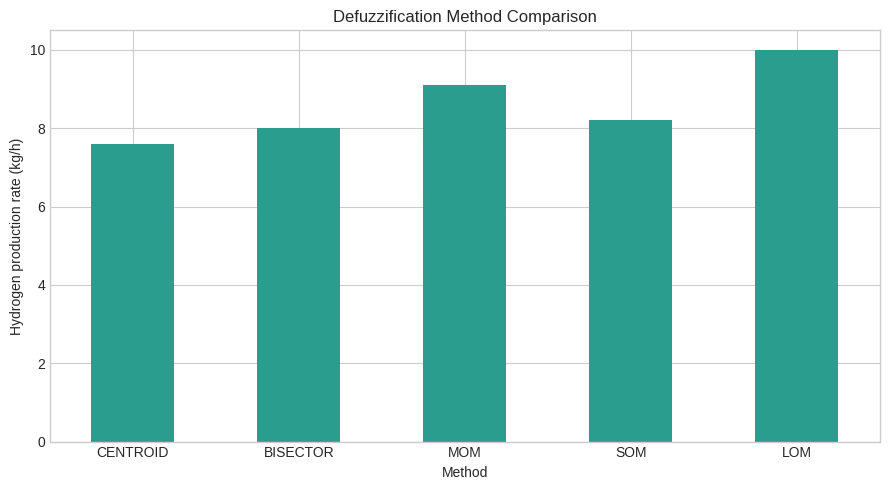

In [ ]:
methods = ['centroid', 'bisector', 'mom', 'som', 'lom']
comparison = []
for method in methods:
    _, result = run_controller(sample_reading, method, show_output=False)
    comparison.append({'Method': method.upper(), 'Hydrogen rate (kg/h)': result})

comparison_df = pd.DataFrame(comparison)
display(comparison_df.style.format({'Hydrogen rate (kg/h)': '{:.2f}'}))

ax = comparison_df.plot.bar(x='Method', y='Hydrogen rate (kg/h)', legend=False, figsize=(9, 5), color='#2a9d8f')
ax.set_ylabel('Hydrogen production rate (kg/h)')
ax.set_title('Defuzzification Method Comparison')
ax.set_ylim(0, 10.5)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Step 13: Test different plant operating cases

The following scenarios are deterministic validation cases derived from the controller’s qualitative intent. They are not measured plant data.


In [ ]:
test_cases = pd.DataFrame([
    {'Case': 'Nominal renewable operation', 'renewable_power': 70, 'water_flow': 14, 'stack_temperature': 50, 'tank_pressure': 35},
    {'Case': 'Low renewable availability', 'renewable_power': 15, 'water_flow': 10, 'stack_temperature': 50, 'tank_pressure': 35},
    {'Case': 'High-pressure protection', 'renewable_power': 15, 'water_flow': 3, 'stack_temperature': 50, 'tank_pressure': 85},
    {'Case': 'High-temperature derating', 'renewable_power': 60, 'water_flow': 10, 'stack_temperature': 75, 'tank_pressure': 35},
    {'Case': 'High renewable and safe pressure', 'renewable_power': 85, 'water_flow': 18, 'stack_temperature': 50, 'tank_pressure': 25},
])

case_results = []
for _, row in test_cases.iterrows():
    reading = row.drop('Case').to_dict()
    _, result = run_controller(reading, 'centroid', show_output=False)
    case_results.append({**row.to_dict(), 'Hydrogen rate (kg/h)': result})

case_results_df = pd.DataFrame(case_results)
display(case_results_df.style.format({
    'renewable_power': '{:.0f}', 'water_flow': '{:.0f}',
    'stack_temperature': '{:.0f}', 'tank_pressure': '{:.0f}',
    'Hydrogen rate (kg/h)': '{:.2f}'
}))


,Case,renewable_power,water_flow,stack_temperature,tank_pressure,Hydrogen rate (kg/h)
0,Nominal renewable operation,70,14,50,35,7.59
1,Low renewable availability,15,10,50,35,3.00
2,High-pressure protection,15,3,50,85,0.71
3,High-temperature derating,60,10,75,35,3.00
4,High renewable and safe pressure,85,18,50,25,8.83


### Plot the test-case outputs


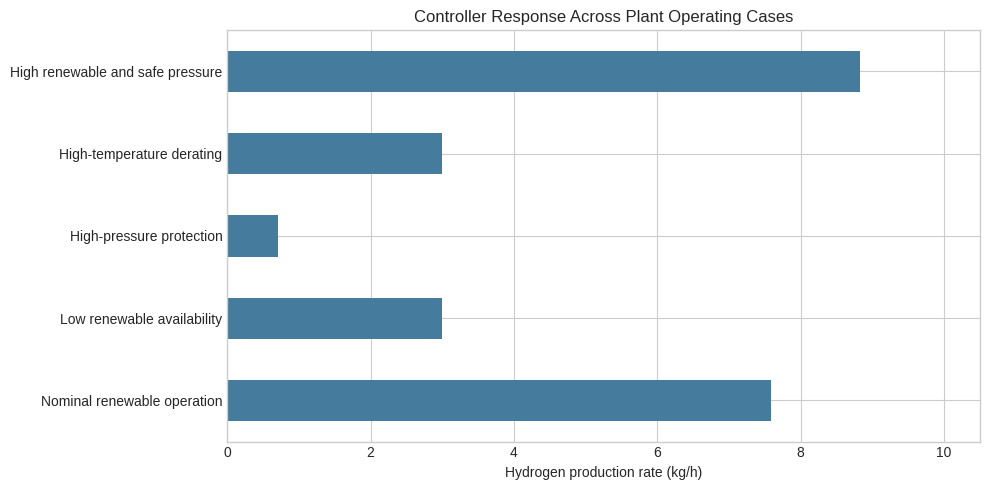

In [ ]:
ax = case_results_df.plot.barh(x='Case', y='Hydrogen rate (kg/h)', legend=False, figsize=(10, 5), color='#457b9d')
ax.set_xlabel('Hydrogen production rate (kg/h)')
ax.set_ylabel('')
ax.set_title('Controller Response Across Plant Operating Cases')
ax.set_xlim(0, 10.5)
plt.tight_layout()
plt.show()


## Step 14: Conclusions

The fuzzy controller converts imprecise engineering conditions into a human-readable production command. Renewable availability and water flow support production, while high tank pressure and high stack temperature reduce the command through the rule base. The sample calculation demonstrates why the same sensor snapshot can produce slightly different numerical outputs under centroid, bisector, maximum-based, or PDF-style weighted-average defuzzification.

For a real deployment, the model would require calibration against electrolyzer performance data, explicit sensor validation, rate limits and ramp constraints, emergency shutdown logic, pressure and temperature hard limits, and hardware-in-the-loop or pilot testing.

### References

1. Supplied project PDF, *Autonomous Green Hydrogen Plant Controller*, L. D. College of Engineering, Gujarat Technological University.
2. L. A. Zadeh, “Fuzzy Sets,” *Information and Control*, 1965.
3. E. H. Mamdani and S. Assilian, “An Experiment in Linguistic Synthesis with a Fuzzy Logic Controller,” *International Journal of Man-Machine Studies*, 1975.
4. scikit-fuzzy documentation and source package, used for the computational implementation.


## Final SCADA interface from the supplied implementation

This final cell embeds the interactive React/Tailwind SCADA dashboard supplied in `Untitled1.ipynb`. It is intentionally kept as a browser-facing view, while the Python implementation above remains the computation reference.

In [ ]:
from IPython.display import display, HTML
import base64

fuzzy_scada_html = """<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8" />
  <meta name="viewport" content="width=device-width, initial-scale=1.0" />
  <title>Autonomous Green Hydrogen Plant Fuzzy Controller</title>
  <script src="https://cdn.tailwindcss.com"></script>
  <script src="https://unpkg.com/react@18/umd/react.production.min.js"></script>
  <script src="https://unpkg.com/react-dom@18/umd/react-dom.production.min.js"></script>
  <script src="https://unpkg.com/@babel/standalone/babel.min.js"></script>
</head>
<body class="bg-slate-950 text-slate-100 font-mono select-none">
  <div id="root"></div>

  <script type="text/babel">
    const { useState, useEffect, useRef } = React;

    // Triangular Membership Function calculation
    function calcTriMF(x, a, b, c) {
      if (a === b && x <= b) return 1.0;
      if (b === c && x >= b) return 1.0;
      if (x <= a || x >= c) return 0.0;
      if (x === b) return 1.0;
      if (x < b) return (x - a) / (b - a);
      return (c - x) / (c - b);
    }

    function FuzzyElectrolyzerApp() {
      // 4 Input Parameters (Default preset to the worked example in the project)
      const [powerConfig, setPowerConfig] = useState({ val: 70.0, min: 0.0, max: 100.0, unit: 'kW' });
      const [waterConfig, setWaterConfig] = useState({ val: 14.0, min: 0.0, max: 20.0, unit: 'L/min' });
      const [pressConfig, setPressConfig] = useState({ val: 35.0, min: 0.0, max: 100.0, unit: 'bar' });
      const [tempConfig, setTempConfig] = useState({ val: 50.0, min: 20.0, max: 80.0, unit: '°C' });

      // Output Range Configuration
      const [outputConfig, setOutputConfig] = useState({ min: 0.0, max: 10.0, unit: 'kg/h' });

      const [systemActive, setSystemActive] = useState(true);
      const [showRangeEditor, setShowRangeEditor] = useState(false);
      const [activeTab, setActiveTab] = useState('scada'); // 'scada' | 'rules' | 'mf_graph'
      const [history, setHistory] = useState([]);

      const canvasRef = useRef(null);
      const mfCanvasRef = useRef(null);

      // Safe numeric parser
      const parseNum = (val, fallback = 0) => {
        const parsed = parseFloat(val);
        return isNaN(parsed) ? fallback : parsed;
      };

      const P = parseNum(powerConfig.val, 0);
      const W = parseNum(waterConfig.val, 0);
      const PR = parseNum(pressConfig.val, 0);
      const T = parseNum(tempConfig.val, 20);

      // 1. Fuzzification (Calculate degree of memberships)
      const uPower = {
        Low: calcTriMF(P, 0, 0, 50),
        Medium: calcTriMF(P, 25, 50, 75),
        High: calcTriMF(P, 50, 100, 100)
      };

      const uWater = {
        Low: calcTriMF(W, 0, 0, 10),
        Medium: calcTriMF(W, 5, 10, 15),
        High: calcTriMF(W, 10, 20, 20)
      };

      const uPress = {
        Low: calcTriMF(PR, 0, 0, 50),
        Medium: calcTriMF(PR, 25, 50, 75),
        High: calcTriMF(PR, 50, 100, 100)
      };

      const uTemp = {
        Low: calcTriMF(T, 20, 20, 40),
        Normal: calcTriMF(T, 30, 50, 70),
        High: calcTriMF(T, 60, 80, 80)
      };

      // 2. Mamdani Fuzzy Rule Inference (11 Expert Rules)
      const rules = [
        { id: 'R1', name: 'R1: P(High) & W(High) & PR(Low) & T(Norm)', w: Math.min(uPower.High, uWater.High, uPress.Low, uTemp.Normal), term: 'High' },
        { id: 'R2', name: 'R2: P(High) & W(Low) & PR(Low) & T(Norm)', w: Math.min(uPower.High, uWater.Low, uPress.Low, uTemp.Normal), term: 'Medium' },
        { id: 'R3', name: 'R3: P(Med) & W(Med) & PR(Low) & T(Norm)', w: Math.min(uPower.Medium, uWater.Medium, uPress.Low, uTemp.Normal), term: 'Medium' },
        { id: 'R4', name: 'R4: P(Med) & W(Low) & PR(Low) & T(Norm)', w: Math.min(uPower.Medium, uWater.Low, uPress.Low, uTemp.Normal), term: 'Medium' },
        { id: 'R5', name: 'R5: P(Low) & W(High) & PR(Low) & T(Norm)', w: Math.min(uPower.Low, uWater.High, uPress.Low, uTemp.Normal), term: 'Medium' },
        { id: 'R6', name: 'R6: P(Low) & W(Med) & PR(Low) & T(Norm)', w: Math.min(uPower.Low, uWater.Medium, uPress.Low, uTemp.Normal), term: 'Low' },
        { id: 'R7', name: 'R7: P(Low) & W(Low) & PR(Low) & T(Norm)', w: Math.min(uPower.Low, uWater.Low, uPress.Low, uTemp.Normal), term: 'Low' },
        { id: 'R8', name: 'R8: P(High) & W(High) & PR(Med) & T(Norm)', w: Math.min(uPower.High, uWater.High, uPress.Medium, uTemp.Normal), term: 'High' },
        { id: 'R9', name: 'R9: P(High) & W(Med) & PR(Med) & T(Norm)', w: Math.min(uPower.High, uWater.Medium, uPress.Medium, uTemp.Normal), term: 'Medium' },
        { id: 'R10', name: 'R10: P(Low) & W(Low) & PR(High) & T(Norm)', w: Math.min(uPower.Low, uWater.Low, uPress.High, uTemp.Normal), term: 'Off' },
        { id: 'R11', name: 'R11: P(Med) & W(Any) & PR(Any) & T(High)', w: Math.min(uPower.Medium, 1.0, 1.0, uTemp.High), term: 'Low' }
      ];

      // 3. Rule Aggregation by Maximum Firing Strength
      const termWeights = {
        Off: Math.max(0, ...rules.filter(r => r.term === 'Off').map(r => r.w)),
        Low: Math.max(0, ...rules.filter(r => r.term === 'Low').map(r => r.w)),
        Medium: Math.max(0, ...rules.filter(r => r.term === 'Medium').map(r => r.w)),
        High: Math.max(0, ...rules.filter(r => r.term === 'High').map(r => r.w))
      };

      // 4. Defuzzification via Peak Weighted Average (Peaks: Off=1, Low=3, Med=6, High=10)
      const peaks = { Off: 1.0, Low: 3.0, Medium: 6.0, High: 10.0 };
      const sumWeights = termWeights.Off + termWeights.Low + termWeights.Medium + termWeights.High;
      const sumWeightedPeaks = (termWeights.Off * peaks.Off) + (termWeights.Low * peaks.Low) + (termWeights.Medium * peaks.Medium) + (termWeights.High * peaks.High);

      // Base defuzzified output
      let fuzzyH2Yield = sumWeights > 0 ? (sumWeightedPeaks / sumWeights) : 0.0;

      // Dynamic output scaling based on configured output range
      const scaledOutput = systemActive ? ((fuzzyH2Yield / 10.0) * (outputConfig.max - outputConfig.min) + outputConfig.min) : 0.0;
      const h2Output = Math.min(outputConfig.max, Math.max(outputConfig.min, parseFloat(scaledOutput.toFixed(2))));

      // Safety matrix checks
      const isTempCritical = T >= 78.0;
      const isPressCritical = PR >= 95.0;

      // Telemetry recorder FIFO
      useEffect(() => {
        const timer = setInterval(() => {
          setHistory((prev) => [
            ...prev.slice(-39),
            { power: P, waterFlow: W, stackTemp: T, tankPressure: PR, h2Rate: h2Output }
          ]);
        }, 1000);
        return () => clearInterval(timer);
      }, [P, W, T, PR, h2Output]);

      // Telemetry Trend Canvas
      useEffect(() => {
        const canvas = canvasRef.current;
        if (!canvas) return;
        const ctx = canvas.getContext('2d');
        const { width, height } = canvas;
        ctx.clearRect(0, 0, width, height);

        ctx.strokeStyle = '#1e293b';
        ctx.lineWidth = 1;
        for (let i = 0; i <= 8; i++) {
          const y = (i / 8) * height;
          ctx.beginPath(); ctx.moveTo(0, y); ctx.lineTo(width, y); ctx.stroke();
        }

        if (history.length < 2) return;

        const drawTrace = (key, maxVal, color) => {
          ctx.strokeStyle = color;
          ctx.lineWidth = 2;
          ctx.beginPath();
          history.forEach((d, i) => {
            const x = (i / (history.length - 1)) * width;
            const y = height - (d[key] / maxVal) * (height - 12) - 6;
            if (i === 0) ctx.moveTo(x, y);
            else ctx.lineTo(x, y);
          });
          ctx.stroke();
        };

        drawTrace('power', powerConfig.max || 100, '#fbbf24');
        drawTrace('waterFlow', waterConfig.max || 20, '#22d3ee');
        drawTrace('stackTemp', tempConfig.max || 80, '#f97316');
        drawTrace('tankPressure', pressConfig.max || 100, '#a855f7');
        drawTrace('h2Rate', outputConfig.max || 10, '#34d399');
      }, [history, activeTab, powerConfig, waterConfig, tempConfig, pressConfig, outputConfig]);

      // Fuzzy Output Membership Function Viewer Canvas
      useEffect(() => {
        const canvas = mfCanvasRef.current;
        if (!canvas || activeTab !== 'mf_graph') return;
        const ctx = canvas.getContext('2d');
        const { width, height } = canvas;
        ctx.clearRect(0, 0, width, height);

        // Grid
        ctx.strokeStyle = '#1e293b';
        ctx.lineWidth = 1;
        for (let i = 0; i <= 5; i++) {
          const y = (i / 5) * height;
          ctx.beginPath(); ctx.moveTo(0, y); ctx.lineTo(width, y); ctx.stroke();
        }

        const mfs = [
          { name: 'Off', a: 0, b: 0, c: 2, peak: 1, w: termWeights.Off, color: '#94a3b8' },
          { name: 'Low', a: 1, b: 3, c: 5, peak: 3, w: termWeights.Low, color: '#38bdf8' },
          { name: 'Medium', a: 4, b: 6, c: 8, peak: 6, w: termWeights.Medium, color: '#fbbf24' },
          { name: 'High', a: 7, b: 10, c: 10, peak: 10, w: termWeights.High, color: '#34d399' }
        ];

        // Draw fuzzy output triangles & clipped levels
        mfs.forEach(mf => {
          ctx.strokeStyle = mf.color;
          ctx.lineWidth = 1.5;
          ctx.beginPath();
          for (let xVal = 0; xVal <= 10; xVal += 0.1) {
            const xPix = (xVal / 10.0) * width;
            const mu = calcTriMF(xVal, mf.a, mf.b, mf.c);
            const yPix = height - (mu * (height - 20)) - 10;
            if (xVal === 0) ctx.moveTo(xPix, yPix);
            else ctx.lineTo(xPix, yPix);
          }
          ctx.stroke();

          // Fill clipped area if fired
          if (mf.w > 0) {
            ctx.fillStyle = mf.color + '33';
            ctx.beginPath();
            ctx.moveTo((mf.a / 10) * width, height - 10);
            for (let xVal = mf.a; xVal <= mf.c; xVal += 0.1) {
              const xPix = (xVal / 10.0) * width;
              const mu = Math.min(mf.w, calcTriMF(xVal, mf.a, mf.b, mf.c));
              const yPix = height - (mu * (height - 20)) - 10;
              ctx.lineTo(xPix, yPix);
            }
            ctx.lineTo((mf.c / 10) * width, height - 10);
            ctx.closePath();
            ctx.fill();
          }
        });

        // Draw defuzzified centroid line
        if (h2Output > 0) {
          const xDefuzz = (fuzzyH2Yield / 10.0) * width;
          ctx.strokeStyle = '#f43f5e';
          ctx.lineWidth = 2.5;
          ctx.setLineDash([5, 5]);
          ctx.beginPath();
          ctx.moveTo(xDefuzz, 0);
          ctx.lineTo(xDefuzz, height);
          ctx.stroke();
          ctx.setLineDash([]);
        }
      }, [activeTab, termWeights, fuzzyH2Yield, h2Output]);

      return (
        <div className="min-h-screen bg-slate-950 p-4 md:p-6 text-slate-100 font-mono">

          {/* Header */}
          <div className="flex flex-wrap justify-between items-center pb-4 mb-6 border-b border-slate-800 gap-4">
            <div>
              <div className="flex items-center gap-2">
                <span className="w-3 h-3 rounded-full bg-emerald-400 animate-pulse"></span>
                <h1 className="text-xl font-bold uppercase text-white tracking-wide">
                  AUTONOMOUS GREEN H₂ PLANT CONTROLLER (FUZZY LOGIC)
                </h1>
              </div>
              <p className="text-xs text-slate-400 mt-0.5">L. D. College of Engineering / GTU Mamdani FLC Model</p>
            </div>

            <div className="flex items-center gap-3">
              <div className="flex bg-slate-900 border border-slate-800 rounded p-0.5 text-xs font-bold">
                <button onClick={() => setActiveTab('scada')} className={`px-3 py-1.5 rounded transition ${activeTab === 'scada' ? 'bg-emerald-600 text-white' : 'text-slate-400'}`}>SCADA Flow</button>
                <button onClick={() => setActiveTab('rules')} className={`px-3 py-1.5 rounded transition ${activeTab === 'rules' ? 'bg-emerald-600 text-white' : 'text-slate-400'}`}>11 Rules Matrix</button>
                <button onClick={() => setActiveTab('mf_graph')} className={`px-3 py-1.5 rounded transition ${activeTab === 'mf_graph' ? 'bg-emerald-600 text-white' : 'text-slate-400'}`}>Fuzzy Membership Graph</button>
              </div>

              <button
                onClick={() => setShowRangeEditor(!showRangeEditor)}
                className={`px-3 py-1.5 text-xs font-bold rounded border transition ${
                  showRangeEditor ? 'bg-amber-500 text-black border-amber-400' : 'bg-slate-900 border-slate-700 text-slate-300 hover:bg-slate-800'
                }`}
              >
                {showRangeEditor ? 'Close Range Settings' : '⚙ Edit Ranges'}
              </button>

              <button
                onClick={() => setSystemActive(!systemActive)}
                className={`px-4 py-1.5 text-xs font-bold rounded text-white transition ${
                  systemActive ? 'bg-rose-600 hover:bg-rose-700' : 'bg-emerald-600 hover:bg-emerald-700'
                }`}
              >
                {systemActive ? 'EMERGENCY TRIP' : 'PERMISSIVE START'}
              </button>
            </div>
          </div>

          {/* Range Configuration Settings Drawer */}
          {showRangeEditor && (
            <div className="bg-slate-900 border-2 border-amber-500/50 p-4 rounded-xl mb-6 shadow-xl">
              <span className="text-xs font-bold uppercase text-amber-400 block mb-3">⚙ Modify Min & Max Boundary Envelopes</span>
              <div className="grid grid-cols-2 sm:grid-cols-3 lg:grid-cols-5 gap-3 text-xs">
                <div className="p-3 bg-slate-950 rounded border border-slate-800">
                  <span className="font-bold text-amber-400 block mb-1">⚡ Power ({powerConfig.unit})</span>
                  <div className="flex gap-1.5">
                    <input type="number" value={powerConfig.min} onChange={(e) => setPowerConfig({...powerConfig, min: parseNum(e.target.value, 0)})} className="w-1/2 bg-slate-900 border border-slate-700 rounded px-1.5 py-0.5 text-right text-white text-xs" placeholder="Min" />
                    <input type="number" value={powerConfig.max} onChange={(e) => setPowerConfig({...powerConfig, max: parseNum(e.target.value, 100)})} className="w-1/2 bg-slate-900 border border-slate-700 rounded px-1.5 py-0.5 text-right text-white text-xs" placeholder="Max" />
                  </div>
                </div>

                <div className="p-3 bg-slate-950 rounded border border-slate-800">
                  <span className="font-bold text-cyan-400 block mb-1">💧 Water ({waterConfig.unit})</span>
                  <div className="flex gap-1.5">
                    <input type="number" value={waterConfig.min} onChange={(e) => setWaterConfig({...waterConfig, min: parseNum(e.target.value, 0)})} className="w-1/2 bg-slate-900 border border-slate-700 rounded px-1.5 py-0.5 text-right text-white text-xs" placeholder="Min" />
                    <input type="number" value={waterConfig.max} onChange={(e) => setWaterConfig({...waterConfig, max: parseNum(e.target.value, 20)})} className="w-1/2 bg-slate-900 border border-slate-700 rounded px-1.5 py-0.5 text-right text-white text-xs" placeholder="Max" />
                  </div>
                </div>

                <div className="p-3 bg-slate-950 rounded border border-slate-800">
                  <span className="font-bold text-orange-400 block mb-1">🌡 Temp ({tempConfig.unit})</span>
                  <div className="flex gap-1.5">
                    <input type="number" value={tempConfig.min} onChange={(e) => setTempConfig({...tempConfig, min: parseNum(e.target.value, 20)})} className="w-1/2 bg-slate-900 border border-slate-700 rounded px-1.5 py-0.5 text-right text-white text-xs" placeholder="Min" />
                    <input type="number" value={tempConfig.max} onChange={(e) => setTempConfig({...tempConfig, max: parseNum(e.target.value, 80)})} className="w-1/2 bg-slate-900 border border-slate-700 rounded px-1.5 py-0.5 text-right text-white text-xs" placeholder="Max" />
                  </div>
                </div>

                <div className="p-3 bg-slate-950 rounded border border-slate-800">
                  <span className="font-bold text-purple-400 block mb-1">🛢 Pressure ({pressConfig.unit})</span>
                  <div className="flex gap-1.5">
                    <input type="number" value={pressConfig.min} onChange={(e) => setPressConfig({...pressConfig, min: parseNum(e.target.value, 0)})} className="w-1/2 bg-slate-900 border border-slate-700 rounded px-1.5 py-0.5 text-right text-white text-xs" placeholder="Min" />
                    <input type="number" value={pressConfig.max} onChange={(e) => setPressConfig({...pressConfig, max: parseNum(e.target.value, 100)})} className="w-1/2 bg-slate-900 border border-slate-700 rounded px-1.5 py-0.5 text-right text-white text-xs" placeholder="Max" />
                  </div>
                </div>

                <div className="p-3 bg-slate-950 rounded border-2 border-emerald-500/60">
                  <span className="font-bold text-emerald-400 block mb-1">🚀 Output ({outputConfig.unit})</span>
                  <div className="flex gap-1.5">
                    <input type="number" value={outputConfig.min} onChange={(e) => setOutputConfig({...outputConfig, min: parseNum(e.target.value, 0)})} className="w-1/2 bg-slate-900 border border-slate-700 rounded px-1.5 py-0.5 text-right text-white text-xs" placeholder="Min" />
                    <input type="number" value={outputConfig.max} onChange={(e) => setOutputConfig({...outputConfig, max: parseNum(e.target.value, 10)})} className="w-1/2 bg-slate-900 border border-slate-700 rounded px-1.5 py-0.5 text-right text-white text-xs" placeholder="Max" />
                  </div>
                </div>
              </div>
            </div>
          )}

          {/* Main Content Area */}
          <div className="grid grid-cols-1 lg:grid-cols-12 gap-6 mb-6">

            {/* 4 Process Inputs Column (Typing + Sliders) */}
            <div className="lg:col-span-7 bg-slate-900 border border-slate-800 p-5 rounded-xl space-y-4">
              <span className="text-xs font-bold uppercase text-slate-300 block mb-1">⚡ 4 Process Telemetry Inputs (Type or Drag)</span>

              {/* Input 1: Power */}
              <div className="p-3 bg-slate-950 rounded-lg border border-slate-800/80">
                <div className="flex justify-between items-center text-xs mb-1.5">
                  <span className="text-amber-400 font-bold">⚡ Renewable Power</span>
                  <div className="flex items-center gap-1.5">
                    <input
                      type="number" step="any" value={powerConfig.val}
                      onChange={(e) => setPowerConfig({ ...powerConfig, val: e.target.value === '' ? '' : parseNum(e.target.value, 0) })}
                      className="w-20 bg-slate-900 border border-slate-700 focus:border-amber-400 rounded px-2 py-0.5 text-right font-black text-amber-400 text-xs focus:outline-none"
                    />
                    <span className="text-slate-400 text-xs font-bold">{powerConfig.unit}</span>
                  </div>
                </div>
                <input
                  type="range" min={powerConfig.min} max={powerConfig.max} step="0.5" value={P}
                  onChange={(e) => setPowerConfig({ ...powerConfig, val: parseFloat(e.target.value) })}
                  className="w-full accent-amber-400 bg-slate-800 h-1.5 rounded cursor-pointer"
                />
                <div className="flex justify-between text-[10px] text-slate-500 mt-1">
                  <span>μLow: {uPower.Low.toFixed(2)} | μMed: {uPower.Medium.toFixed(2)} | μHigh: {uPower.High.toFixed(2)}</span>
                  <span>Max: {powerConfig.max} kW</span>
                </div>
              </div>

              {/* Input 2: Water Feed */}
              <div className="p-3 bg-slate-950 rounded-lg border border-slate-800/80">
                <div className="flex justify-between items-center text-xs mb-1.5">
                  <span className="text-cyan-400 font-bold">💧 Water Flow Rate</span>
                  <div className="flex items-center gap-1.5">
                    <input
                      type="number" step="any" value={waterConfig.val}
                      onChange={(e) => setWaterConfig({ ...waterConfig, val: e.target.value === '' ? '' : parseNum(e.target.value, 0) })}
                      className="w-20 bg-slate-900 border border-slate-700 focus:border-cyan-400 rounded px-2 py-0.5 text-right font-black text-cyan-400 text-xs focus:outline-none"
                    />
                    <span className="text-slate-400 text-xs font-bold">{waterConfig.unit}</span>
                  </div>
                </div>
                <input
                  type="range" min={waterConfig.min} max={waterConfig.max} step="0.1" value={W}
                  onChange={(e) => setWaterConfig({ ...waterConfig, val: parseFloat(e.target.value) })}
                  className="w-full accent-cyan-400 bg-slate-800 h-1.5 rounded cursor-pointer"
                />
                <div className="flex justify-between text-[10px] text-slate-500 mt-1">
                  <span>μLow: {uWater.Low.toFixed(2)} | μMed: {uWater.Medium.toFixed(2)} | μHigh: {uWater.High.toFixed(2)}</span>
                  <span>Max: {waterConfig.max} L/min</span>
                </div>
              </div>

              {/* Input 3: Stack Temp */}
              <div className={`p-3 bg-slate-950 rounded-lg border transition-all ${isTempCritical ? 'border-rose-500 bg-rose-950/20' : 'border-slate-800/80'}`}>
                <div className="flex justify-between items-center text-xs mb-1.5">
                  <span className="text-orange-400 font-bold">🌡 Stack Temperature</span>
                  <div className="flex items-center gap-1.5">
                    <input
                      type="number" step="any" value={tempConfig.val}
                      onChange={(e) => setTempConfig({ ...tempConfig, val: e.target.value === '' ? '' : parseNum(e.target.value, 20) })}
                      className="w-20 bg-slate-900 border border-slate-700 focus:border-orange-400 rounded px-2 py-0.5 text-right font-black text-orange-400 text-xs focus:outline-none"
                    />
                    <span className="text-slate-400 text-xs font-bold">{tempConfig.unit}</span>
                  </div>
                </div>
                <input
                  type="range" min={tempConfig.min} max={tempConfig.max} step="0.5" value={T}
                  onChange={(e) => setTempConfig({ ...tempConfig, val: parseFloat(e.target.value) })}
                  className="w-full accent-orange-400 bg-slate-800 h-1.5 rounded cursor-pointer"
                />
                <div className="flex justify-between text-[10px] text-slate-500 mt-1">
                  <span>μLow: {uTemp.Low.toFixed(2)} | μNorm: {uTemp.Normal.toFixed(2)} | μHigh: {uTemp.High.toFixed(2)}</span>
                  <span className="text-rose-400">Trip: 78 °C</span>
                </div>
              </div>

              {/* Input 4: Tank Pressure */}
              <div className={`p-3 bg-slate-950 rounded-lg border transition-all ${isPressCritical ? 'border-rose-500 bg-rose-950/20' : 'border-slate-800/80'}`}>
                <div className="flex justify-between items-center text-xs mb-1.5">
                  <span className="text-purple-400 font-bold">🛢 Tank Pressure</span>
                  <div className="flex items-center gap-1.5">
                    <input
                      type="number" step="any" value={pressConfig.val}
                      onChange={(e) => setPressConfig({ ...pressConfig, val: e.target.value === '' ? '' : parseNum(e.target.value, 0) })}
                      className="w-20 bg-slate-900 border border-slate-700 focus:border-purple-400 rounded px-2 py-0.5 text-right font-black text-purple-400 text-xs focus:outline-none"
                    />
                    <span className="text-slate-400 text-xs font-bold">{pressConfig.unit}</span>
                  </div>
                </div>
                <input
                  type="range" min={pressConfig.min} max={pressConfig.max} step="0.5" value={PR}
                  onChange={(e) => setPressConfig({ ...pressConfig, val: parseFloat(e.target.value) })}
                  className="w-full accent-purple-400 bg-slate-800 h-1.5 rounded cursor-pointer"
                />
                <div className="flex justify-between text-[10px] text-slate-500 mt-1">
                  <span>μLow: {uPress.Low.toFixed(2)} | μMed: {uPress.Medium.toFixed(2)} | μHigh: {uPress.High.toFixed(2)}</span>
                  <span className="text-rose-400">Vent: 95 bar</span>
                </div>
              </div>
            </div>

            {/* Output Display & Fuzzy Breakdown */}
            <div className="lg:col-span-5 bg-slate-900 border-2 border-emerald-500/50 p-6 rounded-xl flex flex-col justify-between shadow-xl">
              <div>
                <div className="flex justify-between items-center mb-3">
                  <span className="text-xs font-bold uppercase text-emerald-400">🚀 Calculated Mamdani Output</span>
                  <span className="text-[10px] px-2 py-0.5 rounded bg-emerald-950 border border-emerald-700 text-emerald-300">
                    {systemActive ? 'DEFUZZIFIED' : 'ESD TRIP'}
                  </span>
                </div>

                <div className="text-center py-6 bg-slate-950 rounded-xl border border-slate-800 mb-4">
                  <div className="text-xs uppercase text-slate-400 font-bold tracking-widest">Hydrogen Production Rate (y*)</div>
                  <div className="text-5xl font-black text-emerald-400 my-2 tracking-tight">
                    {h2Output.toFixed(2)}
                  </div>
                  <div className="text-xs text-slate-400 font-bold">{outputConfig.unit} (Range: {outputConfig.min} – {outputConfig.max})</div>

                  <div className="w-3/4 mx-auto bg-slate-800 h-2 rounded-full mt-4 overflow-hidden">
                    <div
                      className="bg-emerald-400 h-full transition-all duration-300"
                      style={{ width: `${Math.min(100, Math.max(0, ((h2Output - outputConfig.min) / ((outputConfig.max - outputConfig.min) || 1)) * 100))}%` }}
                    />
                  </div>
                </div>

                {/* Defuzzification Weights Breakdown */}
                <div className="grid grid-cols-4 gap-1.5 text-center text-xs mb-4">
                  <div className="p-2 bg-slate-950 border border-slate-800 rounded">
                    <span className="text-[10px] text-slate-500 block">w(Off)</span>
                    <span className="font-bold text-slate-300">{termWeights.Off.toFixed(2)}</span>
                  </div>
                  <div className="p-2 bg-slate-950 border border-slate-800 rounded">
                    <span className="text-[10px] text-slate-500 block">w(Low)</span>
                    <span className="font-bold text-sky-400">{termWeights.Low.toFixed(2)}</span>
                  </div>
                  <div className="p-2 bg-slate-950 border border-slate-800 rounded">
                    <span className="text-[10px] text-slate-500 block">w(Med)</span>
                    <span className="font-bold text-amber-400">{termWeights.Medium.toFixed(2)}</span>
                  </div>
                  <div className="p-2 bg-slate-950 border border-slate-800 rounded">
                    <span className="text-[10px] text-slate-500 block">w(High)</span>
                    <span className="font-bold text-emerald-400">{termWeights.High.toFixed(2)}</span>
                  </div>
                </div>
              </div>

              {/* Status matrix */}
              <div className="p-3 bg-slate-950 rounded-lg border border-slate-800 text-xs space-y-1.5">
                <div className="flex justify-between">
                  <span className="text-slate-400">Centroid Calculation:</span>
                  <span className="text-white font-mono">Σ(w×Peak) / Σw = {sumWeightedPeaks.toFixed(2)} / {sumWeights.toFixed(2)}</span>
                </div>
                <div className="flex justify-between">
                  <span className="text-slate-400">Daily Yield Estimate:</span>
                  <span className="text-emerald-400 font-bold font-mono">{(h2Output * 24).toFixed(1)} kg / day</span>
                </div>
              </div>
            </div>

          </div>

          {/* Conditional View Tabs */}
          {activeTab === 'rules' && (
            <div className="bg-slate-900 border border-slate-800 rounded-xl p-5 mb-6">
              <span className="text-xs font-bold uppercase tracking-wider text-slate-300 block mb-3">11 IF-THEN Rules Matrix & Live Firing Weights</span>
              <div className="grid grid-cols-1 md:grid-cols-2 gap-2 text-xs">
                {rules.map(r => (
                  <div key={r.id} className={`p-2.5 rounded border flex justify-between items-center ${r.w > 0 ? 'bg-emerald-950/40 border-emerald-700' : 'bg-slate-950 border-slate-800/80 text-slate-500'}`}>
                    <span>{r.name} ➔ <strong className="text-white">{r.term}</strong></span>
                    <span className={`font-mono font-bold px-2 py-0.5 rounded text-[11px] ${r.w > 0 ? 'bg-emerald-900 text-emerald-300' : 'bg-slate-900 text-slate-600'}`}>
                      w = {r.w.toFixed(2)}
                    </span>
                  </div>
                ))}
              </div>
            </div>
          )}

          {activeTab === 'mf_graph' && (
            <div className="bg-slate-900 border border-slate-800 rounded-xl p-5 mb-6">
              <div className="flex justify-between items-center mb-2">
                <span className="text-xs font-bold uppercase tracking-wider text-slate-300">Fuzzy Output Membership Functions & Defuzzified Centroid (y*)</span>
                <div className="flex gap-3 text-[10px]">
                  <span className="text-slate-400">● Off</span>
                  <span className="text-sky-400">● Low</span>
                  <span className="text-amber-400">● Med</span>
                  <span className="text-emerald-400">● High</span>
                  <span className="text-rose-500 font-bold">--- y* Defuzzified</span>
                </div>
              </div>
              <canvas ref={mfCanvasRef} width={800} height={180} className="w-full h-44 bg-slate-950 rounded border border-slate-800" />
            </div>
          )}

          {/* Telemetry Live Trend Monitor */}
          <div className="bg-slate-900 border border-slate-800 rounded-lg p-4">
            <div className="flex justify-between items-center mb-2">
              <span className="text-xs font-bold uppercase tracking-wider text-slate-300">Live 40s Multi-Trace Telemetry Monitor</span>
              <div className="flex gap-3 text-[10px]">
                <span className="text-amber-400">● Power</span>
                <span className="text-cyan-400">● Water</span>
                <span className="text-orange-400">● Temp</span>
                <span className="text-purple-400">● Pressure</span>
                <span className="text-emerald-400">● H₂ Output</span>
              </div>
            </div>
            <canvas ref={canvasRef} width={800} height={150} className="w-full h-36 bg-slate-950 rounded border border-slate-800" />
          </div>

        </div>
      );
    }

    const root = ReactDOM.createRoot(document.getElementById('root'));
    root.render(<FuzzyElectrolyzerApp />);
  </script>
</body>
</html>
"""
encoded = base64.b64encode(fuzzy_scada_html.encode("utf-8")).decode("utf-8")
display(HTML(f'<iframe src="data:text/html;base64,{encoded}" style="width:100%; height:940px; border:none; border-radius:8px;"></iframe>'))

/usr/local/lib/python3.13/dist-packages/IPython/core/display.py:724: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")
